# RNN을 사용한 문장 생성

5장과 6장에서는 RNN과 LSTM의 구조와 구현을 자세하게 살펴봤음   
이번 장에서는 지금까지의 성과(RNN과 LSTM)가 결과를 보여줌   
LSTM을 이용해 재미있는 애플리케이션을 구현해볼 것이기 때문   

이번 장에서는 언어 모델을 사용해 '문장 생성'을 수행함   
구체적으로는 우선 말뭉치를 사용해 학습한 언어 모델을 이용하여 새로운 문장을 만들어냄   
그런 다음 개선된 언어 모델을 이용하여 더 자연스러운 문장을 생성하는 모습도 살펴볼 것   
여기까지 해보면 'AI로 글을 쓰게 한다'라는 개념을 (간단하게라도) 실감할 수 있을 것   

여기서 멈추지 않고 seq2seq라는 새로운 구조의 신경망도 다룸   
seq2seq란 '(from) sequence to sequence(시계열에서 시계열로)'를 뜻하는 말로, 한 시계열 데이터를 다른 시계열 데이터로 변환하는 걸 말함   
이번 장에서는 RNN 두 개를 연결하는 아주 간단한 방법으로 seq2seq를 구현해볼 것   
이 seq2seq는 기계 번역, 챗봇, 메일의 자동 답신 등 다양하게 응용될 수 있음   
이 간단하면서 영리하고 강력한 seq2seq를 이해하고 나면 딥러닝의 가능성이 더욱 크게 느껴질 것

## 언어 모델을 사용한 문장 생성

지금까지 여러 장에 걸쳐서 언어 모델을 다뤄왔음   
언어 모델은 다양한 애플리케이션에서 활용할 수 있음   
대표적인 예로는 기게 번역, 음성 인식, 문장 생성 등이 있음   
이번 절에서는 언어 모델로 문장을 생성해보려 함

### RNN을 사용한 문장 생성의 순서

앞 장에서는 LSTM 계층을 이용하여 언어 모델을 구현했는데, 그 모델의 신경망 구성은 아래 그림처럼 생겼었음   
그리고 시계열 데이터를 (T개분 만큼) 모아 처리하는 Time LSTM과 Time Affine 계층 등을 만들었음   
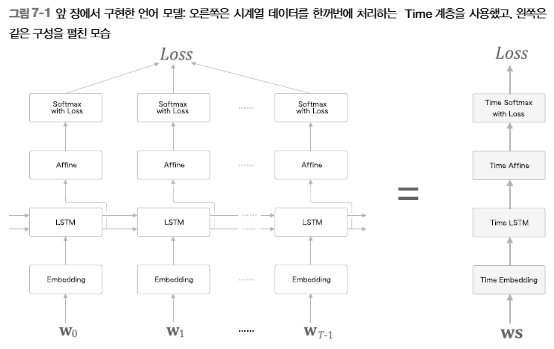   

이제 언어 모델에게 문장을 생성시키는 순서를 설명해보면   
이번에도 이전에 사용했던 "you say goodbye and I say hello."라는 말뭉치로 학습한 언어 모델을 예로 생각해봄   
이 학습된 언어 모델에 'I'라는 단어를 입력으로 주면 이 언어 모델은 다음과 같은 확률분포를 출력한다고 함   
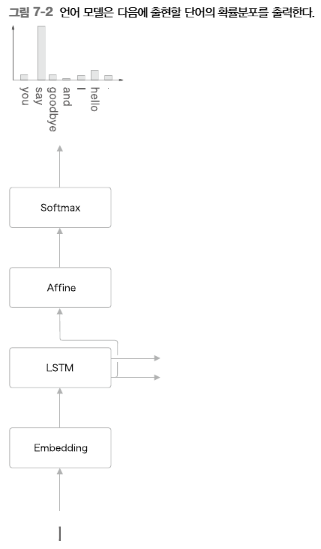   
- 언어 모델은 지금까지 주어진 단어들에서 다음에 출현하는 단어의 확률분포를 출력함   
- 그림의 예는 'I'라는 단어를 주었을 때 출력한 확률분포를 보여줌
- 이 결과를 기초로 다음 단어를 새로 생성하려면 어떻게 해야 하는지?   

첫 번째로, 확률이 가장 높은 단어를 선택하는 방법을 떠올릴 수 있음   
확률이 가장 높은 단어를 선택할 뿐이므로 결과가 일정하게 정해지는 '결정적'인 방법   
또한, '확률적'으로 선택하는 방법도 생각할 수 있음   
각 후보 단어의 확률에 맞게 선택하는 것으로, 확률이 높은 단어는 선택되기 쉽고, 확률이 낮은 단어는 선택되기 어려워짐   
이 방식에서는 선택되는 단어(샘플링 단어)가 매번 다를 수 있음   

여기서는 매번 다른 문장을 생성하도록 함   
그 편이 생성되는 문장이 다양해져서 재미있을 것이기 때문   
그래서 후자의 방법(확률적으로 선택하는 방법)으로 단어를 선택하도록 함   
원래 예시로 돌아와서, 아래 그림과 같이 'say'라는 단어가 (확률적으로) 선택되었다고 하면   
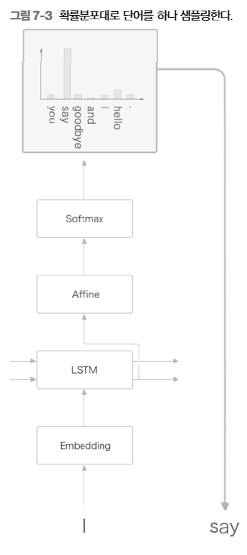   
- 그림은 확률분포로부터 샘플링을 수행한 결과로 'say'가 선택된 경우를 보여줌
- 실제로 그림의 확률분포에서는 'say'의 확률이 가장 높기 때문에 'say'가 샘플링될 확률이 가장 높기도 함
- 다만, 필연적이지는 않고('결정적'이 아니고) '확률적'으로 결정된다는 점에 주의
- 다른 단어들도 해당 단어의 출현 확률에 따라 정해진 비율만큼 샘플링될 가능성이 있다는 뜻   

> 결정적(deterministic)이란 (알고리즘의) 결과가 하나로 정해지는 것, 결과가 예측 가능한 것을 말함   
> 예컨대 앞의 예에서 확률이 가장 높은 단어를 선택하도록 하면, 그것은 '결정적'인 알고리즘   
> 한편, 확률적(probabilistic)인 알고리즘에서는 결과가 확률에 따라 정해짐   
> 따라서 선택되는 단어는 실행할 때마다 달라짐(혹은 달라질 수 있음)   

그러면 계속해서 두 번째 단어를 샘플링   
이 작업은 앞에서 한 작업을 되풀이하기만 하면 됨   
즉, 방금 생성한 단어인 'say'를 언어 모델에 입력하여 다음 단어의 확률분포를 얻음   
그런 다음 그 확률분포를 기초로 다음에 출현할 단어를 샘플링하는 것   
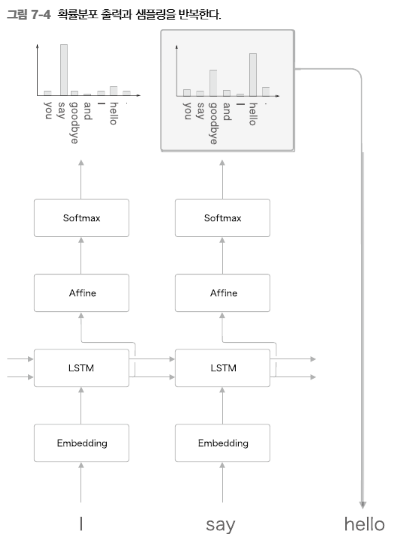   

다음은 이 작업을 원하는 만큼 반복함(또는 \<eos> 같은 종결 기호가 나타날 때까지 반복함)   
그러면 새로운 문장을 생성할 수 있음   

여기에서 주목할 것은 이렇게 생성한 문장은 훈련 데이터에는 존재하지 않는, 말 그대로 새로 생성된 문장이라는 것   
언어 모델은 훈련 데이터를 암기한 것이 아니라, 훈련 데이터에서 사용된 단어의 정렬 패턴을 학습한 것이기 때문   
만약 언어 모델이 말뭉치로부터 단어의 출현 패턴을 올바르게 학습할 수 있다면, 그 모델이 새로 생성하는 문장은 우리 인간에게도 자연스럽고 의미가 통하는 문장일 것으로 기대할 수 있음

### 문장 생성 구현

그럼 문장을 생성하는 코드를 구현해보기   
앞 장에서 구현한 Rnnlm 클래스를 상속해 RnnlmGen 클래스를 만들고, 이 클래스에 문장 생성 메서드를 추가함   

> 클래스 상속이란 기존 클래스를 계승하여 새로운 클래스를 만드는 메커니즘   
> 파이썬에서 클래스를 상속하려면   
> 기반 클래스 이름이 'Base'이고 새로 정의할 클래스 이름이 'New'라면 class New(Base)라고 쓰면 됨

In [1]:
import sys
sys.path.append('..')
import numpy as np
from common.functions import softmax
from ch06.rnnlm import Rnnlm
from ch06.better_rnnlm import BetterRnnlm

class RnnlmGen(Rnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]

        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x)
            p = softmax(score.flatten())

            sampled = np.random.choice(len(p), size=1, p=p)
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(int(x))


        return word_ids

- 이 클래스에서 문장 생성을 수행하는 메서드는 generate(start_id, skip_ids, sample_size)
- 인수 중 start_id는 최초로 주는 단어의 ID, sample_size는 샘플링하는 단어의 수를 말함
- 그리고 skip_ids는 단어 ID의 리스트인데(예컨데 [12, 20]), 이 리스트에 속하는 단어 ID는 샘플링되지 않도록 해줌
- 이 인수는 PTB 데이터셋에 있는 \<unk>나 N 등, 전처리된 단어를 샘플링하지 않게 하는 용도로 사용함   

> PTB 데이터셋은 원래의 문장들에 이미 전처리를 해둔 것으로, 희소한 단어는 \<unk>로, 숫자는 N으로 대체해놨음   
> 참고로, 이 책의 예에서는 각 문장을 구분하는 데 \<eos>라는 문자열을 사용함   

- generate() 메서드는 가장 먼저 model.predict(x)를 호출해 각 단어의 점수를 출력함(점수는 정규화되기 전의 값)
- 그리고 p = softmax(score) 코드에서는 이 점수들을 소프트맥스 함수를 이용해 정규화함
- 이것으로 목표로 하는 p를 얻을 수 있음
- 그런 다음 확률분포 p로부터 다음 단어를 샘플링함
- 확률분포로부터 샘플링할 때는 np.random.choice()를 사용함   

> model의 predict() 메서드는 미니배치 처리를 하므로 입력 x는 2차원 배열이어야 함   
> 그래서 단어 ID를 하나만 입력하더라도 미니배치 크기를 1로 간주해 1 x 1 넘파이 배열로 성형(reshape)함   

이 RnnlmGen 클래스를 사용해 문장을 생성해보기   
이번에는 아무런 학습도 수행하지 않은 상태에서(즉, 가중치 매개변수는 무작위 초깃값인 상태에서) 문장을 생성함

In [2]:
import sys
sys.path.append('..')
from dataset import ptb


corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
corpus_size = len(corpus)

model = RnnlmGen()
# model.load_params('../ch06/Rnnlm.pkl')

# start 문자와 skip 문자 설정
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>', '$']
skip_ids = [word_to_id[w] for w in skip_words]

# 문장 생성
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print(txt)

you southwestern strike his nickel shanghai college windsor shake datapoint rebuffed belgium volumes naming actually hong fabrication steppenwolf revolving strategists colonial crown bids acted transit dead jolla awareness mural exercise torrijos robbed gillett apogee needed basic offenders unpaid remaining freeway casino broke enough guard slipped hardest announcing friend another advanced weight stream institution privatization cheney peripheral hitting staging banxquote greater release pipes premiere operators increased developers slumped airports culmination l.a. improper thin want phrase durkin wedge whooping drawing examined visitors disease chooses watched convenient double-digit dinner barney districts kravis sits gutfreund future surgical hectic ignore lately valued capitalize cushion drugs


C:\Users\ESDL\AppData\Local\Temp\ipykernel_33996\3001100787.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  word_ids.append(int(x))


- 여기에서는 첫 단어를 'you'로 하고, 그 단어 ID를 start_id로 설정한 다음 문장을 생성함
- 샘플링하지 않은 단어로는 ['N', '\<unk>', '$']를 지정함
- 문장을 생성하는 generate() 메서드는 단어 ID들을 배열 형태로 반환함
- 그래서 그 단어 ID 배열을 문장으로 변환해야 하는데, txt = ' '.join([id_to_word[i] for i in word_ids]) 코드가 그 일을 담당함
- join() 메서드는 [구분자].join(리스트) 형태로 작성하며, 리스트의 단어들 사이에 구분자를 삽입해 모두 연결함   

위 코드를 실행해보면   
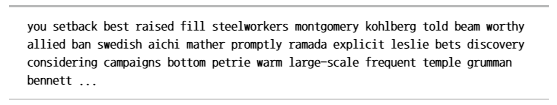   
- 이 그림처럼 단어들을 엉터리로 나열한 글이 출력됨
- 당연하게도, 모델의 가중치 초깃값으로 무작위한 값을 사용했기 때문에 의미가 통하지 않는 문장이 출력된 것
- 그렇다면 학습을 수행한 모델이라면 어떻게 다를지?   

바로 이어서, 앞 장에서 학습을 끝낸ㄴ 가중치를 이용해 문장을 생성해봄   
위 코드에서 주석 처리해둔 model.load_params('../ch06/Rnnlm.pkl') 줄을 통해 앞 장에서 학습한 가중치 매개변수를 읽어 들임   
주석을 해제하고 문장을 생성해보면   

In [3]:
model = RnnlmGen()
model.load_params('../ch06/Rnnlm.pkl')

# start 문자와 skip 문자 설정
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>', '$']
skip_ids = [word_to_id[w] for w in skip_words]

# 문장 생성
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print(txt)

C:\Users\ESDL\AppData\Local\Temp\ipykernel_33996\3001100787.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  word_ids.append(int(x))


you view head of the world 's zero of the marriage of its immediate credit and markets and political factor.
 but fiercely huge links here and greater action against the world hope contends why can read town and then so to shape that the devastation imbalances the german country said.
 the u.s. white house had five major games to insure wage.
 the state department of carriers should combine operations of time inc. as it developed the congress to play answers to having a network by many smaller shares.
 but could n't immediately be quite rid.



- 문법적으로 이상하거나 의미가 통하지 않는 문장이 섞여 있지만, 그럴듯한 문장도 있음
- 자세히 보면 주어와 동사를 짝지어 올바른 순서호 배치한 문장들이 보임
- 형용사와 명사의 사용법도 어느 정도 이해하는 것처럼 보임   

이처럼 두 번째 시도로 생성한 문장은 어느 정도는 올바른 문장이라고 할 수 있을 것   
하지만 부자연스러운 문장도 발견되니, 아직 개선할 여지가 있음   
'완변한 문장'은 존재하지 않지만, 더 자연스러운 문장이 필요함   
그러기 위해서는 당연히 더 나은 언어 모델을 쓰면 됨

### 더 좋은 문장으로

좋은 언어 모델이 있으면 좋은 문장을 기대할 수 있음   
앞 장에서는 단순한 RNNLM을 개선해 '더 좋은 RNNLM'을 구현했음   
퍼플렉서티가 대략 136이던 모델을 75까지 개선했었음   

> 앞 장에서는 BetterRnnlm 클래스를 학습시켜 학습된 가중치를 파일로서 저장했음   
> 이번 절의 실험은 그 학습된 가중치 파일을 사용함   
> 책에서는 미리 학습시켜둔 가중치 파일을 제공함   
> https://www.oreilly.co.jp/pub/9784873118369/BetterRnnlm.pkl

앞 장에서는 더 좋은 언어 모델을 BetterRnnlm라는 클래스로 구현했음   
여기에서는 방금 전과 마찬가지로 이 클래스를 상속한 후 문장 생성 기능을 추가함

In [4]:
import sys
sys.path.append('..')
import numpy as np
from common.functions import softmax
from ch06.rnnlm import Rnnlm
from ch06.better_rnnlm import BetterRnnlm

class BetterRnnlmGen(BetterRnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]

        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x)
            p = softmax(score.flatten())

            sampled = np.random.choice(len(p), size=1, p=p)
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(int(x))


        return word_ids

그럼 더 좋은 모델로 문장을 생성해보기   
앞서와 같이 첫 문자로는 'you'를 줌

In [7]:
import sys
sys.path.append('..')
from common.np import *
from dataset import ptb


corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
corpus_size = len(corpus)


model = BetterRnnlmGen()
model.load_params('../ch06/BetterRnnlm.pkl')

# start 문자와 skip 문자 설정
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>', '$']
skip_ids = [word_to_id[w] for w in skip_words]

# 문장 생성
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')

print(txt)

C:\Users\ESDL\AppData\Local\Temp\ipykernel_33996\2214011197.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  word_ids.append(int(x))


you might have gotten money says john jobs who took over circuit virginia who expires.
 illegal business narrows us to support strength right for an audience mr. sells said.
 a group of two executives are bracing for blue-chip businesses wherever the noise of a chemicals company were he disclosed in august he said.
 the price buys more than its firm debt.
 both are led by morgan stanley & co. will buy shares at least half of its assets in the 20-year.
 mr. bernstein said he is trying to increase mr. green 's decision to the


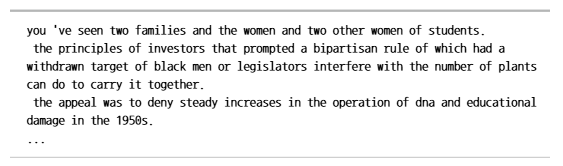   
- 결과를 보면 (주관적이지만) 저번보다 자연스러운 문장이 만들어진 것 같아 보임
- 첫 문장에서는 주어, 동사, 목적어를 올바르게 사용했음
- 게다가 'and'의 사용법도 잘 학습했음
- 다른 문장을 읽어봐도, 이 정도면 전체적으로 상당히 좋은 결과라고 할 수 있음   

여기에서 생성된 문장에는 아직 문제가 몇 개 남아 있지만(특히 의미적인 측면에서)   
지금 만든 '더 좋은 언어 모델'은 (어느 정도) 자연스러운 문장을 자유롭게 생성해내는 것 같음   
분면, 이 모델을 한 단계 더 개선하고 한층 더 큰 말뭉치를 사용하면 더 자연스러운 문장을 생성해줄 것   

마지막으로, 이 모델에 "the meaning of life is"라는 글을 주고 이어지는 말을 생성하라고 해보기   
이 실험을 해보려면, 모델에 ['the', 'meaning', 'of', 'life'] 단어를 차례로 주어 순전파를 수행함   
이때 출력되는 결과는 전혀 사용하지 않지만, LSTM 계층에는 그 단어열 정보가 유지됨   
그런 다음 'is'를 첫 단어로 입력해 문장 생성을 시작시키면 "the meaning of life is"에 이어지는 문장을 생성할 수 있음   

이 실험을 직접 해보면

In [12]:
model.reset_state()

start_words = 'the meaning of life is'
start_ids = [word_to_id[w] for w in start_words.split(' ')]

for x in start_ids[:-1]:
    x = np.array(x).reshape(1, 1)
    model.predict(x)

word_ids = model.generate(start_ids[-1], skip_ids)
word_ids = start_ids[:-1] + word_ids
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print('-' * 50)
print(txt)

C:\Users\ESDL\AppData\Local\Temp\ipykernel_33996\2214011197.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  word_ids.append(int(x))


--------------------------------------------------
the meaning of life is at a more committed credit standard.
 margin emotional.
 tons for american winter examiner makes relief for smokers including people college environmental and experience.
 it may both be the consumer and defense administration the first time the press of course concluded every fda feels that the agency any external network trades at the four holiday suffering or specializing in the yeast is replaced because the future 's entire timing is being used in whooping cough.
 last friday people were scaled back and the success is frustrating.
 an aids gene normally has to vote through claiming


## seq2seq

세상에는 시계열 데이터가 넘쳐남   
언어 데이터, 음성 데이터, 동영상 데이터는 모두 시계열 데이터   
그리고 이러한 시계열 데이터를 또 다른 시계열 데이터로 변환하는 문제도 숱하게 생각할 수 있음   
예컨대 기계 번역이나 음성 인식을 들 수 있음   
그 외에도 챗봇처럼 대화하는 애플리케이션이나 컴파일러처럼 소스 코드를 기계어로 변환하는 작업도 있음   

이처럼 입력과 출력이 시계열 데이터인 문제는 아주 많음   
지금부터 시계열 데이터를 다른 시계열 데이터로 변환하는 모델을 생각해볼 것   
이를 위한 기법으로, 여기에서는 2개의 RNN을 이용하는 **seq2seq(sequence to sequence)** 라는 방법을 살펴볼 것

### seq2seq의 원리

seq2seq를 Encoder-Decoder 모델이라고도 함   
이름이 말해주득이 여기에는 2개의 모듈, Encoder와 Decoder가 등장함   
문자 그대로 Encoder는 입력 데이터를 인코딩(부호화)하고, Decoder는 인코딩된 데이터를 디코딩(복호화)함   

> 인코딩(부호화)이란 정보를 어떤 규칙에 따라 변화하는 것   
> 문자 코드를 예로 들면, 'A'라는 문자를 '1000001'이라는 이진수로 변환하는 식   
> 한편, 디코딩(복호화)이란 인코딩된 정보를 원래의 정보로 되돌리는 것   
> 다시 문자 코드를 예로 들면, '1000001'이라는 비트 패턴을 'A'라는 문자로 변화하는 것   

그럼 seq2seq의 구조를 구체적인 예를 들어 설명   
우리말을 영어로 번역하는 예를 생각해보면   
"나는 고양이로소이다"라는 문장을 "I am a cat"으로 번역해보기   
이때 seq2seq는 아래 그림에서 보듯, Encoder와 Decoder가 시계열 데이터를 변환함   
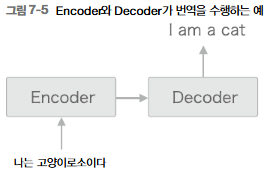   
- 그림처럼 먼저 Encoder가 "나는 고양이로소이다"라는 출발어 문장을 인코딩함
- 이어서 그 인코딩한 정보를 Decoder에 전달하고, Decoder가 도착어 문장을 생성함
- 이때 Encoder가 인코딩한 정보에는 번역에 필요한 정보가 조밀하게 응축되어 있음
- Decoder는 조밀하게 응축된 이 정보를 바탕으로 도착어 문장을 생성하는 것   

이것이 seq2seq의 전체 그림   
Encoder와 Decoder가 협력하여 시계열 데이터를 다른 시계열 데이터로 변환하는 것   
그리고 Encoder와 Decoder로는 RNN을 사용할 수 있음   

이제 전체 과정을 자세히 알아보면   
우선 Encoder의 처리에 집중해서 보면   
Encoder의 계층은 다음과 같이 구성됨   
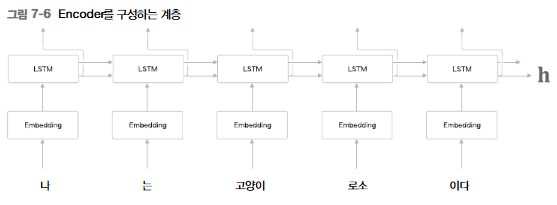   
- 그림처럼 Encoder는 RNN을 이용해 시계열 데이터를 h라는 은닉 상태 벡터로 변환함
- 지금 예에서는 RNN으로써 LSTM을 이용했지만, '단순한 RNN'이나 GRU 등도 물론 이용할 수 있음
- 그리고 여기에서는 우리말 문장을 단어 단위로 쪼개 입력한다고 가정함
- 그런데 그림의 Encoder가 출력하는 벡터 h는 LSTM 계층의 마지막 은닉 상태
- 이 마지막 은닉 상태 h에 입력 문장(출발어)을 번역하는 데 필요한 정보가 인코딩됨
- 여기서 중요한 점은 LSTM의 은닉 상태 h는 고정 길이 벡터라는 것
- 그래서 인코딩한다라 함은 결국 임의 길이의 문장을 고정 길이 벡터로 변환하는 작업이 됨   
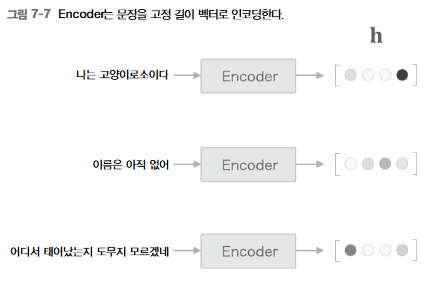   
- 그림에서 보듯 Encoder는 문장을 고정 길이 벡터로 변환함   

그렇다면 Decoder는 이 인코딩된 벡터를 어떻게 하여 도착어 문장을 생성하는 것인지?   
이미 그 답을 알고 있음   
앞 절에서 다룬 문장 생성 모델을 그대로 이용할 수 있기 때문   
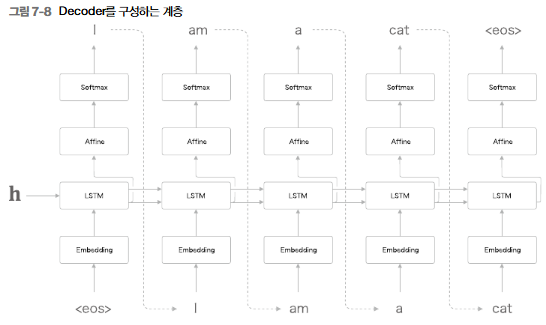   
- 그림과 같이, Decoder는 앞 절의 신경망과 완전히 같은 구성
- 단 한 가지, LSTM 계층이 벡터 h를 입력받는다는 점만 다름
- 앞 절의 언어 모델에서는 LSTM 계층이 아무것도 받지 않았음(굳이 따지자면, 은닉 상태로 '영벡터'를 받았다고 할 수 있음)
- 이처럼 단 하나의 사소한 차이가 평범한 언어 모델을 번역도 해낼 수 있는 Decoder로 바꿈   

> 그림에서는 \<eos>라는 구분 기호(특수 문자)를 이용했음   
> 이 기호는 말 그대로 '구분자'이며, Decoder에 문장 생성의 시작을 알리는 신호로 이용됨   
> 또한, Decoder가 \<eos>를 출력할 때까지 단어를 샘플링하도록 하기 위한 종료 신호이기도 함   
> 즉, \<eos>를 Decoder에 '시작/종료'를 알리는 구분자로 이용한 것   
> 다른 문헌에서는 구분 기호로 \<go>, \<start>, 밑줄(_) 등을 이용하기도 함   

다음은 Decoder와 Encoder를 연결한 계층 구성을 볼 차례   
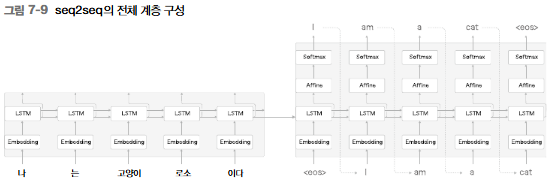   
- 그림에서 보듯 seq2seq는 LSTM 두 개(Encoder의 LSTM과 Decoder의 LSTM)로 구성됨
- 이때 LSTM 계층의 은닉 상태가 Encoder와 Decoder를 이어주는 '가교'가 됨
- 순전파 때는 Encoder에서 인코딩된 정보가 LSTM 계층의 은닉 상태를 통해 Decoder에 전해짐
- 그리고 seq2seq의 역전파 때는 이 '가교'를 통해 기울기가 Decoder로부터 Encoder로 전해짐

### 시계열 데이터 변환용 장난감 문제

이쯤에서 seq2seq를 실제로 구현해볼 것이니, 우선 지금부터 다룰 문제에 관해 설명함   
여기서는 시계열 변환 문제의 예로 '더하기'를 다룰 것   
구체적으로는 "57 + 5"와 같은 문자열을 seq2seq에 건네면 '62'라는 정답을 내놓도록 학습시킬 것   
참고로, 이와 같이 머신러닝을 평가하고자 만든 간단한 문제를 '장난감 문제(toy problem)'라고 함   
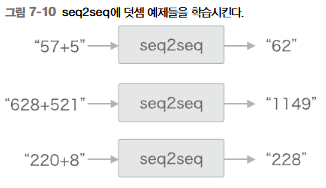   
- 여기서 다루는 덧셈은 우리 인간에게는 쉬운 문제
- 그러나 seq2seq는 덧셈에 대해(더 정확하게 말하면, 덧셈의 논리에 대해) 진짜 아무것도 모름
- seq2seq는 덧셈의 '예(샘플)'로부터, 거기서 사용되는 문자의 패턴을 학습함
- 과연 이런 식으로 해서 덧셈의 규칙을 올바르게 학습할 수 있을지가 이번 문제의 볼거리   

그런데 지금까지 word2vec이나 언어 모델 등에서 문장은 '단어' 단위로 분해해왔음   
하지만 문장을 반드시 단어로 분할해야 하는 것을 아님   
실제로 이번 문제에서는 단어가 아닌 '문자' 단위로 분할하려 함   
문자 단위 분할이란, 에컨대 "57 + 5"가 입력되면 ['5', '7', '+', '5']라는 리스트로 처리하는 걸 말함

### 가변 길이 시계열 데이터

여기선 '덧셈'을 문자(숫자)의 리스트로써 다루기로 했음   
이때 주의할 점은 덧셈 문장("57 + 5"나 "628 + 521" 등)이나 그 대답('62'나 '1149' 등)의 문자 수가 문제마다 다르다는 것   
예컨대 "57 + 5"는 총 4문자이고 "628 + 521"은 총 7문자   

이처럼 이번 '덧셈' 문제에서는 샘플마다 데이터의 시간 방향 크기가 다름   
'가변 길이 시계열 데이터'를 다룬다는 뜻   
따라서 신경망 학습 시 '미니배치 처리'를 하려면 무언가 추가 노력이 필요하게 됨   

> 미니배치로 학습할 때는 다수의 샘플을 한꺼번에 처리함   
> 이때 (지금 구현에서는) 한 미니배치에 속한 샘플들의 데이터 형상이 모두 똑같아야 함   

가변 길이 시계열 데이터를 미니배치로 학습하기 위한 가장 단순한 방법은 **패딩(padding)** 을 사용하는 것   
패딩이란 원래의 데이터에 의미 없는 데이터를 채워 모든 데이터의 길이를 균일하게 맞추는 기법   
아래 그림은 패딩을 이번 덧셈 문제에 적용해본 모습   
모든 입력 데이터의 길이를 통일하고, 남는 공간에는 의미 없는 데이터(여기에서는 '공백')를 채운 걸 볼 수 있음   
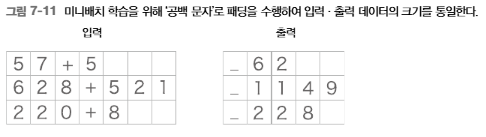   

이번 문제에서는 0 ~ 999 사이의 숫자 2개만 더하기로 함   
따라서 '+'까지 포함하면 입력의 최대 문자 수는 7   
자연스럽게, 덧셈 결과는 최대 4문자(999 + 999 = 1998)   
정답 데이터에도 패딩을 수행해 모든 샘플 데이터의 길이를 통일함   
그리고 질문과 정답을 구분하기 위해 출력 앞에 구분자로 밑줄(_)을 붙이기로 함   
그 결과 출력 데이터는 총 5 문자로 통일   
참고로, 이 구분자는 Decoder에 문자열을 생성하라고 알리는 신호로 사용됨   

> Decoder 출력의 경우, 문자 출력의 종료를 알리는 구분자를 정답 레이블로 입력하도록 구현할 수도 있음(예컨대 '\_62_'나 '\_1149_')   
> 하지만 여기에서는 이야기를 단순화하고자 그런 구분자는 넣지 않음   
> 즉, Decoder가 문자열을 생성할 때는 항상 정해진 수의 문자(여기에서는 '_'를 포함해 5자)만 출력시키도록 함   

이처럼 패딩을 적용해 데이터 크기를 통일시키면 가변 길이 시계열 데이터도 처리할 수 있음   
그러나 원래는 존재하지 않던 패딩용 문자까지 seq2seq가 처리하게 됨   
따라서 패딩을 적용해야 하지만 정확성이 중요하다면 seq2seq에 패딩 전용 처리를 추가해야 함   
- 예컨대 Decoder에 입력된 데이터가 패딩이라면 손실의 결과에 반영하지 않도록 함(Softmax with Loss 계층에 '마스크' 기능을 추가해 해결할 수 있음)   
- 한편 Encoder에 입력된 데이터가 패딩이라면 LSTM 계층이 이전 시각의 입력을 그대로 출력하게 함   
- 즉, LSTM 계층은 마치 처음부터 패딩이 존재하지 않았던 것처럼 인코딩할 수 있음   

이번 장에서는 이해 난이도를 낮추기 위해 패딩용 문자(공백 문자)도 특별히 구분하지 않고 일반 데이터처럼 다룸

### 덧셈 데이터셋

지금부터 사용할 덧셈 학습 데이터는 dataset/addition.txt에 담겨 있음   
이 텍스트 파일에는 덧셈 예가 총 50,000개가 들어 있고, 아래 그림과 같은 형태   
이 학습 데이터는 케라스의 seq2seq 구현 예를 참고해 작성했다고 함   
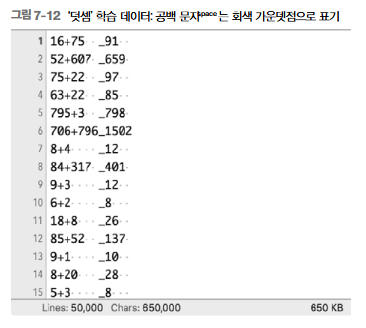   
또한, 이 책에서는 이와 같은 seq2seq용 학습 데이터(텍스트 파일)를 파이썬에서 쉽게 처리할 수 있도록 전용 모듈(dataset/sequence.py)을 제공함   
이 모듈에는 load_data()와 get_vocab()이라는 2개의 메서드가 정의되어 있음   

load_data(file_name, seed)는 file_name으로 지정한 텍스트 파일을 읽어 텍스트를 문자 ID로 변환하고, 이를 훈련 데이터와 테스트 데이터로 나눠 반환함   
seed는 이 메서드 내부에서 사용하는 무작위수의 초깃값   
이 메서드는 훈련 데이터와 테스트 데이터로 나누기 전에 전체 데이터를 뒤섞는데, 이때 무작위수를 사용함   
get_vocab() 메서드는 문자와 문자 ID의 대응 관계를 담은 딕셔너리를 반환함(실제로는 char_to_id와 id_to_char라는 2개의 딕셔너리를 돌려줌)   
실제 사용하는 예를 보면

In [2]:
import sys
sys.path.append('..')
from dataset import sequence


(x_train, t_train), (x_test, t_test) = \
    sequence.load_data('addition.txt', seed=1984)
char_to_id, id_to_char = sequence.get_vocab()

print(x_train.shape, t_train.shape)
print(x_test.shape, t_test.shape)

print(x_train[0])
print(t_train[0])

print(''.join([id_to_char[c] for c in x_train[0]]))
print(''.join([id_to_char[c] for c in t_train[0]]))

(45000, 7) (45000, 5)
(5000, 7) (5000, 5)
[ 3  0  2  0  0 11  5]
[ 6  0 11  7  5]
71+118 
_189 


- 이처럼 sequence 모듈을 이용하면 seq2seq용 데이터를 간단히 읽어 들일 수 있음
- 여기에서 x_train과 t_train에는 '문자 ID'가 저장되어 있음
- 또한, 문자 ID와 문자의 대응 관계는 char_to_id와 id_to_char를 이용해 상호 변환할 수 있음   

> 정석대로라면 데이터셋을 3개(훈련용, 검증용, 테스트용)로 나눠 사용해야 함   
> 훈련용 데이터로는 학습을 하고, 검증용 데이터로는 하이퍼파라미터를 튜닝, 테스트용 데이터로는 모델의 성능을 평가함   
> 다만, 여기에서는 단순하게 하고자, 훈련용과 테스트용으로만 분리하여 모델을 훈련시키고 평가할 것

## seq2seq 구현

seq2seq는 2개의 RNN을 연결한 신경망   
먼저 두 RNN을 Encoder 클래스와 Decoder 클래스로 각각 구현함   
그런 다음 두 클래스를 연결하는 Seq2seq 클래스를 구현   

### Encoder 클래스

Encoder 클래스는 아래 그림처럼 문자열을 받아 벡터 h로 변환   
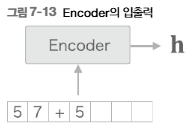   
앞의 내용처럼 RNN을 이용해 Encoder를 구성함   
여기에서는 LSTM 계층을 이용함   
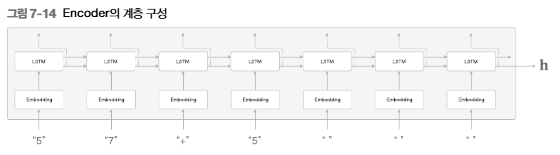   
- 그림과 같이 Encoder 클래스는 Embedding 계층과 LSTM 계층으로 구성됨
- Embedding 계층에서는 문자(정확하게는 문자 ID)를 문자 벡터로 변환
- 그리고 이 문자 벡터가 LSTM 계층으로 입력됨
- LSTM 계층은 오른쪽(시간 방향)으로는 은닉 상태와 셀을 출력하고 위쪽으로는 은닉 상태만 출력함
- 이 구성에서 더 위에는 다른 계층이 없으니 LSTM 계층의 위쪽 출력은 폐기됨
- 그림에서 보듯 Encoder에서는 마지막 문자를 처리한 후 LSTM 계층의 은닉 상태 h를 출력함
- 그리고 이 은닉 상태 h가 Decoder로 전달됨   

> Encoder에서는 LSTM의 은닉 상태만을 Decoder에 전달함   
> LSTM의 셀도 Decoder에 전달할 수는 있지만, LSTM의 셀을 다른 계층에 전달하는 일은 일반적으로 흔치 않음   
> LSTM의 셀은 자기 자신만 사용한다는 전제로 설계되었기 때문   

그런데 책에선 시간 방향을 한꺼번에 처리하는 계층을 Time LSTM 계층이나 Time Embedding 계층으로 구현했음   
이러한 Time 계층을 이용하면 Encoder는 다음처럼 됨   
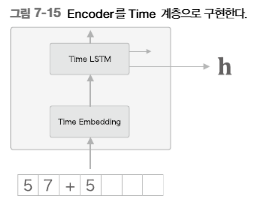   

이제 Encoder 클래스의 코드를 살펴봄   
이 클래스는 차례로 초기화, 순전파, 역전파를 담당하는 \__init__(), forward(), backward() 메서드를 제공   
초기화 메서드부터 보면

In [3]:
import sys
sys.path.append('..')
from common.time_layers import *
from common.base_model import BaseModel


class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=False)

        self.params = self.embed.params + self.lstm.params
        self.grads = self.embed.grads + self.lstm.grads
        self.hs = None

- 초기화 메서드에서는 인수로 vocab_size, wordvec_size, hidden_size를 받음
- vocab_size는 어휘 수이며, 여기서 어휘 수는 문자의 종류를 뜻함
- 참고로 이번에는 0 ~ 9의 숫자와 '+', ' '(공백 문자), '_'을 합쳐 총 13가지 문자를 사용함
- 그리고 wordvec_size는 문자 벡터의 차원 수, hidden_size는 LSTM 계층의 은닉 상태 벡터의 차원 수를 뜻함
- 이 초기화 메서드에서는 가중치 매개변수를 초기화하고, 필요한 계층을 생성
- 마지막으로, 가중치 매개변수와 기울기를 인스턴스 변수 params와 grads 리스트에 각각 보관
- 그리고 이번에는 Time LSTM 계층이 상태를 유지하지 않기 때문에 stateful=False로 설정   

> 5장과 6장의 언어 모델은 '긴 시계열 데이터'가 하나뿐인 문제를 다뤘음   
> Time LSTM 계층의 인수 stateful을 True로 설정하여 은닉 상태를 유지한 채로 '긴 시계열 데이터'를 처리한 것   
> 이번에는 '짧은 시계열 데이터'가 여러 개인 문제   
> 따라서 문제마다 LSTM의 은닉 상태를 다시 초기화한 상태(영벡터)로 설정함   

이어서 forward()와 backward() 메서드를 보면

In [5]:
def forward(self, xs):
    xs = self.embed.forward(xs)
    hs = self.lstm.forward(xs)
    self.hs = hs
    return hs[:, -1, :]

def backward(self, dh):
    dhs = np.zeros_like(self.hs)
    dhs[:, -1, :] = dh

    dout = self.lstm.backward(dhs)
    dout = self.embed.backward(dout)
    return dout

- Encoder의 순전파에서는 Time Embedding 계층과 Time LSTM 계층의 forward() 메서드를 호출
- 그리고 Time LSTM 계층의 마지막 시각의 은닉 상태만을 추출해, 그 값을 Encoder의 forward() 메서드의 출력으로 반환
- Encoder의 역전파에서는 LSTM 계층의 마지막 은닉 상태에 대한 기울기가 dh 인수로 전해짐
- 이 dh는 Decoder가 전해주는 기울기
- 역전파 구현에서는 원소가 모두 0인 텐서 dhs를 생성하고 dh를 dhs의 해당 위치에 할당
- 그다음은 Time LSTM 계층과 Time Embedding 계층의 backward() 메서드를 호출   

여기까지가 Encoder 계층의 구현

In [6]:
import sys
sys.path.append('..')
from common.time_layers import *
from common.base_model import BaseModel


class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=False)

        self.params = self.embed.params + self.lstm.params
        self.grads = self.embed.grads + self.lstm.grads
        self.hs = None

    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        self.hs = hs
        return hs[:, -1, :]

    def backward(self, dh):
        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = dh

        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

### Decoder 클래스

다음은 Decoder 클래스를 구현할 차례   
Decoder 클래스는 아래 그림에서 보듯, Encoder 클래스가 출력한 h를 받아 목적으로 하는 다른 문자열을 출력   
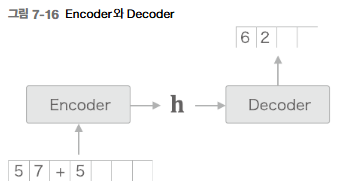   

Decoder는 RNN으로 구현할 수 있음   
Encoder과 마찬가지로 LSTM 계층을 사용하면 되며, 이때 Decoder의 계층 구성은 다음과 같음   
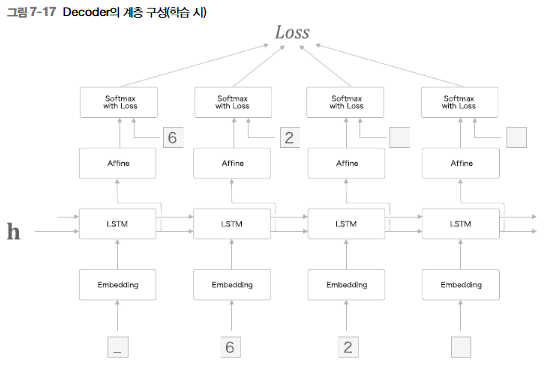   
- 그림은 Decoder의 학습 시 계층 구성을 보여줌
- 여기에서 정답 데이터는 '_62'이지만, 입력 데이터를 ['\_', '6', '2', ' ']로 주고, 이에 대응하는 출력은 ['6', '2', ' ', ' ']이 되도록 학습시킴   

> RNN으로 문장을 생성할 때, 학습 시와 생성 시의 데이터 부여 방법이 다름   
> 학습 시는 정답을 알고 있기 때문에 시계열 방향의 데이터를 한꺼번에 줄 수 있음   
> 추론 시(새로운 문자열을 생성할 때)에는 최초 시작을 알리는 구분 문자(이번 예에서는 '_') 하나만 줌   
> 그리고 그 출력으로부터 문자를 하나 샘플링하여, 그 샘플링한 문자를 다음 입력으로 사용하는 과정을 반복하는 것   

그런데 저번에 문장을 생성할 때는 소프트맥스 함수의 확률분포를 바탕으로 샘플링을 수행했기 때문에 생성되는 문장이 확률에 따라 달라졌음   
이와 달리 이번 문제는 '덧셈'이므로 이러한 확률적인 '비결정성'을 배제하고 '결정적'인 답을 생성하고자 함   
그래서 이번에는 점수가 가장 높은 문자 하나만 고름   
즉, '확률적'이 아닌 '결정적'으로 선택함   
아래 그림은 Decoder가 문자열을 생성시키는 흐름을 보여줌   
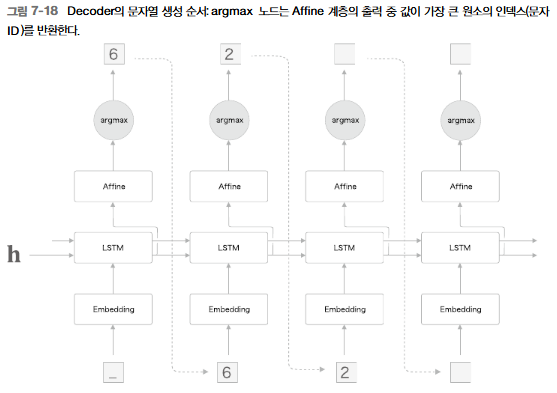   
- 그림에는 'argmax'라는 새로운 노드가 새로 등장
- 최댓값을 가진 원소의 인덱스(이번 예에서는 문자 ID)를 선택하는 노드
- 그림의 구성은 앞 절에서 본 문장 생성 때의 구성과 같음
- 다만 이번에는 Softmax 계층을 사용하지 않고, Affine 계층이 출력하는 점수가 가장 큰 문자 ID를 선택함   

> Softmax 계층은 입력된 벡터를 정규화함   
> 이 정규화 과정에서 벡터의 각 원소의 값이 달라지지만, 대소 관계는 바뀌지 않음   
> 따라서 위 그림의 경우 Softmax 계층을 생략할 수 있음   

여기서 설명한 것처럼 Decoder에서는 학습 시와 생성 시에 Softmax 계층을 다르게 취급함   
그러니 Softmax with Loss 계층은 이후에 구현하는 Seq2seq 클래스에서 처리하기로 하고,   
Decoder 클래스는 아래 그림처럼 Time Softmax with Loss 계층의 앞까지만 담당   
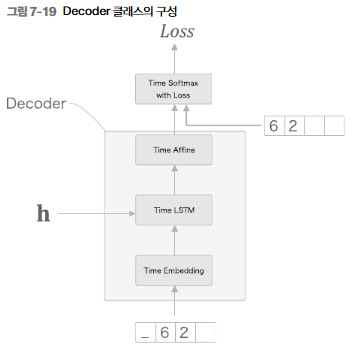   
- 그림과 같이 Decoder 클래스는 Time Embedding, Time LSTM, Time Affine의 3가지 계층으로 구성됨   

그럼 Decoder를 구현해보면

In [7]:
class Decoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, h):
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        out = self.lstm.forward(out)
        score = self.affine.forward(out)
        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        dout = self.lstm.backward(dout)
        dout = self.embed.backward(dout)
        dh = self.lstm.dh
        return dh

    def generate(self, h, start_id, sample_size):
        sampled = []
        sample_id = start_id
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array(sample_id).reshape((1, 1))
            out = self.embed.forward(x)
            out = self.lstm.forward(out)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(int(sample_id))

        return sampled

- backward() 메서드는 위쪽의 Softmax with Loss 계층으로부터 기울기 dscore를 받아 Time Affine 계층, Time LSTM 계층, Time Embedding 계층 순서로 전파시킴
- 이때 Time LSTM 계층의 시간 방향으로의 기울기는 TimeLSTM 클래스의 인스턴스 변수 dh에 저장되어 있음
- 그래서 이 시간 방향의 기울기 dh를 꺼내서 Decoder 클래스의 backward()의 출력으로 반환함
- Decoder 클래스는 학습 시와 문장 생성 시의 동작이 다름
- 앞의 forward() 메서드는 학습할 때 사용된다고 가정했음
- generate() 메서드는 Decoder 클래스에 문장 생성을 담당
- generate() 메서드는 인수를 3개 받음
- Encoder로부터 받는 은닉 상태인 h, 최초로 주어지는 문자 ID인 start_id, 생성하는 문자 수인 sample_size
- 여기에서는 문자를 1개씩 주고, Affine 계층이 출력하는 점수가 가장 큰 문자 ID를 선택하는 작업을 반복

### Seq2seq 클래스

마지막은 Seq2seq 클래스의 구현   
이 클래스가 하는 일은 Encoder 클래스와 Decoder 클래스를 연결하고, Time Softmax with Loss 계층을 이용해 손실을 계산하는 것이 전부

In [8]:
class Seq2seq(BaseModel):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = Decoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

    def forward(self, xs, ts):
        decoder_xs, decoder_ts = ts[:, :-1], ts[:, 1:]

        h = self.encoder.forward(xs)
        score = self.decoder.forward(decoder_xs, h)
        loss = self.softmax.forward(score, decoder_ts)
        return loss

    def backward(self, dout=1):
        dout = self.softmax.backward(dout)
        dh = self.decoder.backward(dout)
        dout = self.encoder.backward(dh)
        return dout

    def generate(self, xs, start_id, sample_size):
        h = self.encoder.forward(xs)
        sampled = self.decoder.generate(h, start_id, sample_size)
        return sampled

- 주가 되는 처리는 Encoder와 Decoder 클래스에 이미 구현되어 있음
- 그래서 여기에서는 그 기능들을 제대로 연결하기만 하면 됨   

다음으로는 이 Seq2seq 클래스를 사용해 '덧셈' 문제에 도전

### seq2seq 평가

seq2seq의 학습은 기본적인 신경망의 학습과 같은 흐름으로 이뤄짐   
1. 학습 데이터에서 미니배치를 선택하고
2. 미니배치로부터 기울기를 계산하고
3. 기울기를 사용하여 매개변수를 갱신   

이런 규칙적인 흐름   
이번 절에서는 '1장 Trainer 클래스' 절에서 설명한 Trainer 클래스를 사용해 이 규칙대로 작업을 수행   
또한, 매 에폭마다 seq2seq가 테스트 데이터를 풀게 하여(문자열 생성을 수행하여) 학습 중간중간 정답률을 측정하고자 함   
seq2seq의 학습 코드를 보면

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.53
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.92
| 에폭 1 |  반복 101 / 351 | 시간 1[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.85
| 에폭 1 |  반복 141 / 351 | 시간 2[s] | 손실 1.83
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.79
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.77
| 에폭 1 |  반복 201 / 351 | 시간 3[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 281 / 351 | 시간 5[s] | 손실 1.75
| 에폭 1 |  반복 301 / 351 | 시간 5[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 6[s] | 손실 1.75
| 에폭 1 |  반복 341 / 351 | 시간 6[s] | 손실 1.74
Q 77+85  
T 162 
X 100 
---
Q 975+164
T 1139
X 1000
---
Q 582+84 
T 666 
X 1000
---
Q 8+155  
T 163 
X 100 
---
Q 367+55 
T 422 
X 1000
---
Q 600+257
T 857 
X 1000
---
Q 761+292
T 1053
X 1000
---
Q 830+597
T 1427
X 1000
---
Q 26+838

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL 

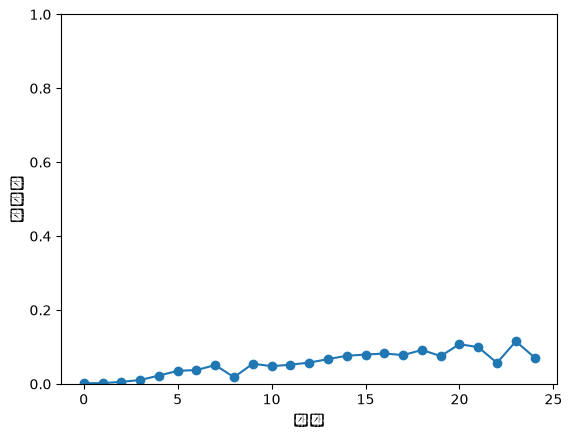

In [10]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 모델 / 옵티마이저 / 트레이너 생성
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

# 그래프 그리기
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(0, 1.0)
plt.show()


- 

- 이상의 코드는 기본적인 신경망의 학습용 코드와 같지만, 평가 척도로 정답률을 사용
- 정확하게는 에폭마다 테스트 데이터의 문제 중 몇 개를 풀게 하여 올바르게 답했는지를 채점
- 이 구현에서  정답률 측정에는 common/utill.py의 eval_seq2seq(model, question, correct, id_to_char, verbose, is_reverse) 메서드를 이용
- 이 메서드는 문제(question)를 모델(model)에 주고, 문자열을 생성하게 하여 그것이 답(correct)과 갖은 지를 판정
- 모델이 내놓은 답이 맞으면 1을 돌려주고 틀리면 0을 돌려줌   

> eval_seq2seq(model, question, correct, id_to_char,verbose, is_reverse) 메서드는 인수를 6개나 받음   
> 처음 3개는 모델을 뜻하는 model, 문제 문장(문자 ID의 배열)인 question, 정답(문자 ID의 배열 )인 correct   
> 그리고 id_to_char는 문자 ID와 문자의 변환을 수행하는 딕셔너리이고, verbose는 결과를 출력할지 여부, is_reverse는 입력문을 반전했는지 여부   
> verbose=True로 설정하면 결과를 터미널로 출력함   
> 이번 실험에서는 테스트 데이터의 최초 10개분만 표시   
> 마지막 인수 is_reverse의 효과는 이후에 설명   

위 코드를 실행하면   
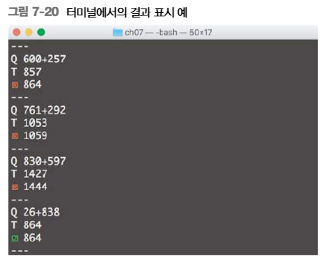   
- 그림과 같이 터미널에는 에폭별 결과가 출력됨
- "Q 600+257" 줄이 문제 문장이고, 그 아래의 "T 857"이 정답
- 그리고 "X 864"는 모델이 내놓은 답   

그럼, 학습을 진행하면서 이 결과가 어떻게 변화해가는지 살펴보면   
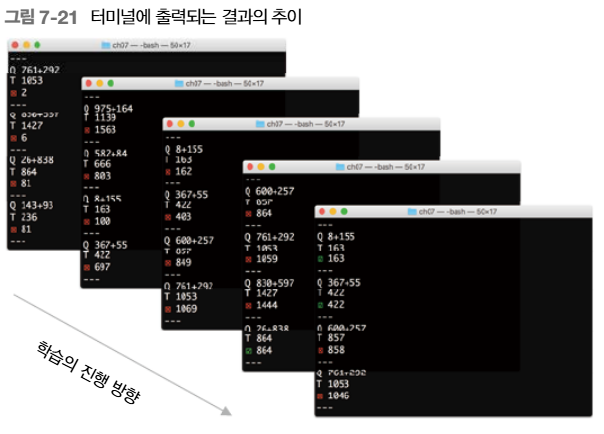   
- 그림은 학습이 진행됨에 따라 출력되는 결과 몇 개를 선택해 보여준 것
- 이 결과를 보면, seq2seq는 초기에는 정답을 잘 맞히지 못함
- 그러나 학습을 거듭할수록 조금씩 정답에 가까워지면서, 몇 개씩은 맞히기 시작함   

그러면 에폭마다의 정답률을 그래프로 살펴보면   
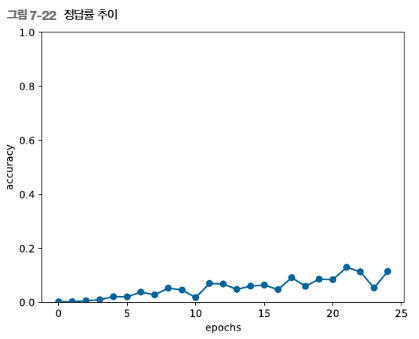   
- 그림처럼 에폭을 거듭함에 따라 정답률이 착실하게 상승하는 것을 알 수 있음
- 이번 실험은 25 에폭에서 중단했는데, 그 시점의 정답률은 10% 정도
- 그래프의 성장 추이를 보면, 학습을 더 거듭하면 더 정확해질 여지가 있어 보임
- 하지만 이 학습은 일단 여기서 끝내고, 같은 문제(덧셈 문제)를 더 잘 학습할 수 있도록 seq2seq를 개선해볼 예정

## seq2seq 개선

이번에는 앞 절의 seq2seq를 세분화하여 학습 '속도'를 개선하고자 함   
효과적인 기법이 몇 가지 있는데, 그중 두 가지 개선안을 소개하고 결과까지 확인할 예정

### 입력 데이터 반전(Reverse)

첫 번째 개선안은 아주 쉬운 트릭으로,   
아래 그림에서 보듯이 입력 데이터의 순서를 반전시키는 것   
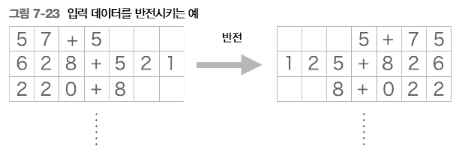   
- 이 트릭을 사용하면 많은 경우 학습 진행이 빨라져서, 결과적으로 최종 정확도도 좋아진다고 함   

입력 데이터를 반전시키려면, 앞 절의 학습용 코드에서 추가하면 됨

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.52
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.91
| 에폭 1 |  반복 101 / 351 | 시간 1[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.86
| 에폭 1 |  반복 141 / 351 | 시간 2[s] | 손실 1.84
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.80
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.78
| 에폭 1 |  반복 201 / 351 | 시간 3[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 241 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 4[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 5[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 5[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 341 / 351 | 시간 6[s] | 손실 1.73
Q 77+85  
T 162 
X 100 
---
Q 975+164
T 1139
X 1000
---
Q 582+84 
T 666 
X 1001
---
Q 8+155  
T 163 
X 100 
---
Q 367+55 
T 422 
X 1001
---
Q 600+257
T 857 
X 1000
---
Q 761+292
T 1053
X 1000
---
Q 830+597
T 1427
X 1000
---
Q 26+838

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL 

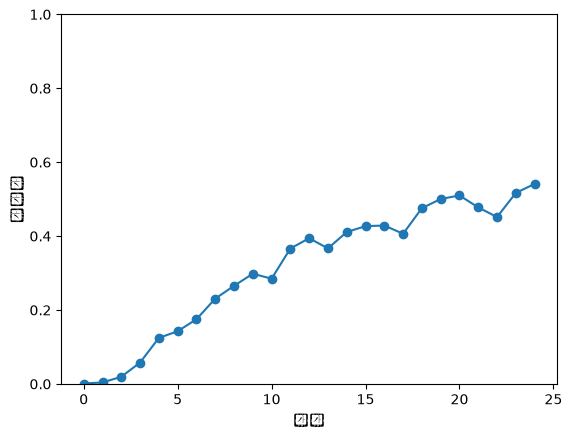

In [11]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 모델 / 옵티마이저 / 트레이너 생성
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

# 그래프 그리기
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(0, 1.0)
plt.show()

- 배열의 행을 반전시키려면 x_train[:, ::-1]이라는 표기법을 사용하면 됨   

그럼 입력 데이터를 반전하는 게 정답률을 얼마나 높여주는지 살펴보면   
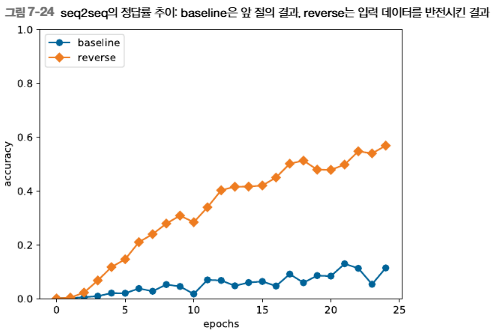   
- 그림에서 보듯, 입력 데이터를 반전시킨 것만으로 학습 진행이 개선됨
- 25 에폭에 이르자 정답률은 50% 정도까지나 오름
- 이전(그래프에서 baseline)과의 차이는 입력 데이터를 반전시킨 것뿐
- 물론, 데이터를 반전시키는 효과는 어떤 문제를 다루느냐에 따라 다르지만, 대부분의 경우 더 좋은 결과로 이어짐   

그러면 왜 입력 데이터를 반전시키는 것만으로 학습의 진행이 빨라지고 정확도가 향상되는 것인지?   
직관적으로는 기울기 전파가 원활해지기 때문이라고 생각됨   

예를 들어 "나는 고양이로소이다"를 "I am a cat"으로 번역하는 문제에서, '나'라는 단어가 'I'로 변환되는 과정을 생각해보면   
이때 '나'로부터 'I'까지 가려면 '는', '고양이', '로소', '이다'까지 총 네 단어 분량의 LSTM 계층을 거치지 않으면 안 됨   
따라서 역전파 시 'I'로부터 전해지는 기울기가 '나'에 도달하기까지, 그 먼 거리만큼 영향을 더 받게 됨   

여기서 입력문을 반전시키면, 즉 "이다  로소 고양이 는" 순으로 바꾸면   
이제 '나'와 'I'는 바로 옆이 되었으니 기울기가 직접 전해짐   
이처럼 입력 문장의 첫 부분에서는 반전 덕분에 대응하는 변환 후 단어와 가까우므로(그런 경우가 많아지므로), 기울기가 더 잘 전해져서 학습 효율이 좋아진다고 생각할 수 있음   
다만, 입력 데이터를 반전해도 단어 사이의 '평균'적인 거리는 그대로임

### 엿보기(Peeky)

이어서 seq2seq의 두 번째 개선   
주제로 들어가기 전에, seq2seq의 Encoder 동작을 한번 더 살펴보면   
Encoder는 입력 문장(문제 문장)을 고정 길이 벡터 h로 변환함   
이때 h 안에는 Decoder에게 필요한 정보가 모두 담겨 있음   
즉, h가 Decoder에 있어서는 유일한 정보인 셈   
그러나 현재의 seq2seq는 아래 그림과 같이 최초 시각의 LSTM 계층만이 벡터 h를 이용하고 있음   
이 중요한 정보인 h를 더 활용할 수는 없는지?   
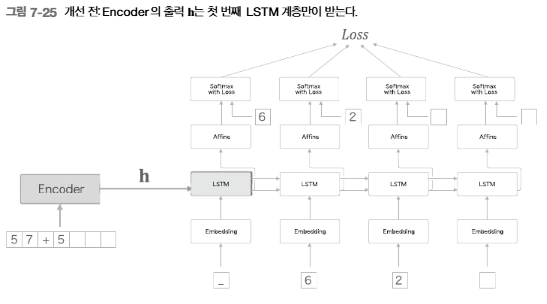   

여기서 seq2seq의 두 번째 개선안이 등장함   
중요한 정보가 담긴 Encoder의 출력 h를 Decoder의 다른 계층에게도 전해주는 것   
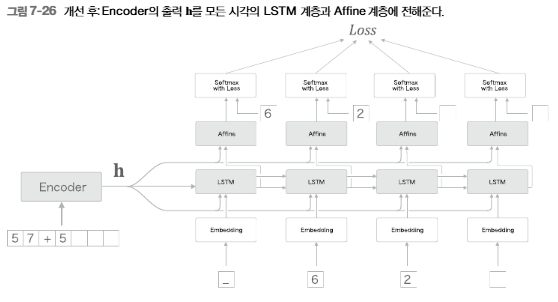   
- 그림과 같이 모든 시각의 Affine 계층과 LSTM 계층에 Encoder의 출력 h를 전해줌
- 이전 그림과 비교해보면, 기존에는 하나의 LSTM만이 소유하던 중요 정보 h를 여러 계층(이 예에서는 총 8개 계층)이 공유함을 알 수 있음
- 이는 집단지성에 비유할 수 있음
- 즉, 중요한 정보를 한 사람이 독점하는 게 아니라 많은 사람과 공유한다면 더 올바른 결정을 내릴 가능성이 커질 것   

> 이 개선안은 인코딩된 정보를 Decoder의 다른 계층에도 전해주는 기법   
> 달리 보면, 다른 계층도 인코딩된 정보를 '엿본다'라고 해석할 수 있음   
> '엿보다'를 영어로 peek이라고 하기 때문에 이 개선을 더한 Decoder를 'Peeky Decoder'라고 함   
> 마찬가지로 Peeky Decoder를 이용하는 seq2seq를 'Peeky seq2seq'라고 함   

그런데 그림에서는 LSTM 계층과 Affine 계층에 입력되는 벡터가 2개씩이 되었음   
이는 실제로는 두 벡터가 연결(concatenate)된 것을 의미   
따라서 앞의 그림은 두 벡터를 연결시키는 concat 노드를 이용해 아래 그림처럼 그려야 정확한 계산 그래프   
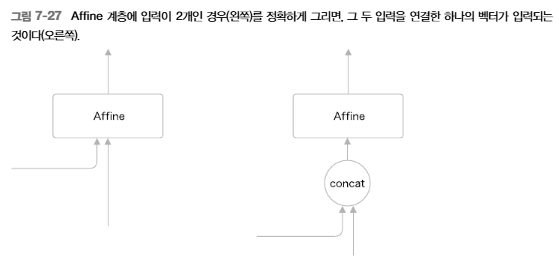   

이제 Peeky Decoder 클래스의 구현을 살펴보면

In [12]:
import sys
sys.path.append('..')
from common.time_layers import *


class PeekyDecoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(H + D, 4 * H) / np.sqrt(H + D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H + H, V) / np.sqrt(H + H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads
        self.cache = None

    def forward(self, xs, h):
        N, T = xs.shape
        N, H = h.shape

        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        hs = np.repeat(h, T, axis=0).reshape(N, T, H)
        out = np.concatenate((hs, out), axis=2)

        out = self.lstm.forward(out)
        out = np.concatenate((hs, out), axis=2)

        score = self.affine.forward(out)
        self.cache = H
        return score

    def backward(self, dscore):
        H = self.cache

        dout = self.affine.backward(dscore)
        dout, dhs0 = dout[:, :, H:], dout[:, :, :H]
        dout = self.lstm.backward(dout)
        dembed, dhs1 = dout[:, :, H:], dout[:, :, :H]
        self.embed.backward(dembed)

        dhs = dhs0 + dhs1
        dh = self.lstm.dh + np.sum(dhs, axis=1)
        return dh

    def generate(self, h, start_id, sample_size):
        sampled = []
        char_id = start_id
        self.lstm.set_state(h)

        H = h.shape[1]
        peeky_h = h.reshape(1, 1, H)
        for _ in range(sample_size):
            x = np.array([char_id]).reshape((1, 1))
            out = self.embed.forward(x)

            out = np.concatenate((peeky_h, out), axis=2)
            out = self.lstm.forward(out)
            out = np.concatenate((peeky_h, out), axis=2)
            score = self.affine.forward(out)

            char_id = np.argmax(score.flatten())
            sampled.append(char_id)

        return sampled

- PeekyDecoder의 초기화는 앞 절의 Decoder와 거의 같음
- 다른 점은 LSTM 계층의 가중치와 Affine 계층의 가중치의 형상뿐
- 이번 구현에서는 Encoder가 인코딩한 벡터도 입력되기 때문에 가중치 매개변수의 형상이 그만큼 커짐
- forward( )의 구현을 보면
- 여기에서는 우선 h를 np.repeat()로 시계열만큼 복제해 hs에 저장함
- 다음은 np.concatenate()를 이용해 그 hs와 Embedding 계층의 출력을 연결하고, 이를 LSTM 계층에 입력함
- 마찬가지로 Affine 계층에도 hs와 LSTM 계층의 출력을 연결한 것을 입력함   

> Encoder 쪽은 앞 절과 똑같음   
> 따라서 앞 절의 Encoder 클래스를 그대로 이용함   

마지막으로, PeekySeq2seq를 구현   
이 클래스는 앞 절의 Seq2seq 클래스와 거의 같음   
유일한 차이는 Decoder 계층   
앞 절의 Seq2seq 클래스가 Decoder 클래스를 사용하던 것에 반해 이번에는 PeekyDecoder를 사용   
그다음 로직은 똑같음   
그래서 PeekySeq2seq 클래스의 구현은 앞 절의 Seq2seq 클래스를 계승하고, 초기화 부분만을 변경

In [13]:
class PeekySeq2seq(Seq2seq):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = PeekyDecoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

이것으로 준비가 완료됨   
이 PeekySeq2seq 클래스를 사용하여 덧셈 문제에 다시 도전해보면
(이번에는 첫 번째 개선인 'Reverse(입력 반전)'도 적용한 후 수행)

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.57
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.48
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.20
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.99
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.89
| 에폭 1 |  반복 101 / 351 | 시간 2[s] | 손실 1.82
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.82
| 에폭 1 |  반복 141 / 351 | 시간 2[s] | 손실 1.80
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.79
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.78
| 에폭 1 |  반복 201 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 5[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 5[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 6[s] | 손실 1.73
| 에폭 1 |  반복 341 / 351 | 시간 6[s] | 손실 1.73
Q 77+85  
T 162 
X 100 
---
Q 975+164
T 1139
X 1013
---
Q 582+84 
T 666 
X 102 
---
Q 8+155  
T 163 
X 100 
---
Q 367+55 
T 422 
X 1023
---
Q 600+257
T 857 
X 1023
---
Q 761+292
T 1053
X 1023
---
Q 830+597
T 1427
X 1111
---
Q 26+838

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL 

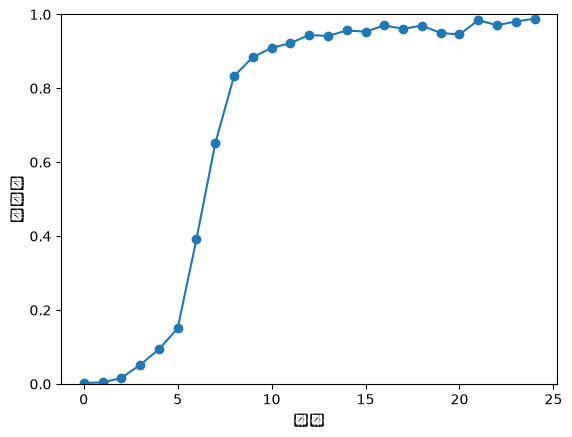

In [14]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 일반 혹은 엿보기(Peeky) 설정 =====================================
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

# 그래프 그리기
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(0, 1.0)
plt.show()

결과를 보면   
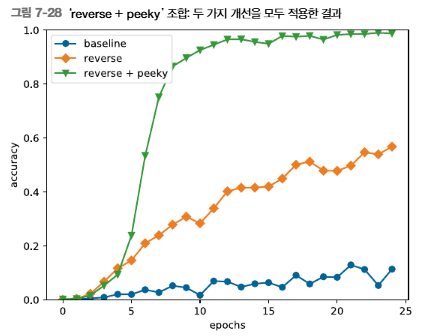   
- 그림에서 보듯 Peeky를 추가로 적용하자 seq2seq의 결과가 월등히 좋아짐
- 10 에폭을 넘어서면서 정답률이 이미 90%를 넘고, 최종적으로는 100%에 가까워짐   

이상의 실험 결과에서 Reverse와 Peeky가 함께 효과적으로 작동하고 있음을 알 수 있음   
입력 문장을 반전시키는 Reverse, 그리고 Encoder의 정보를 널리 퍼지게 하는 Peeky   
이 두 기법 덕분에 만족할 만한 결과를 손에 넣었음   

이것으로 seq2seq 개선은 일단 끝냄   
하지만 이야기는 아직 계속됨   
실은 여기서 수행한 개선은 '작은 개선'이라 할 수 있고, '큰 개선'은 다음 장에서 추가할 계획   
어텐션이라는 기술로, seq2seq를 극적으로 진화시킬 수 있음   

참고로, 이번 절의 실험은 주의해야 함   
Peeky를 이용하게 되면 신경망은 가중치 매개변수가 커져서 계산량도 늘어남   
따라서 이번 절의 실험 결과는 커진 매개변수만큼의 '핸디캡'을 감안해야 함   
또한, seq2seq의 정확도는 하이퍼파라미터에 영향을 크게 받음   
예제에서의 결과는 믿음직했지만, 실제 문제에서는 그 효과가 달라질 것

## seq2seq를 이용하는 애플리케이션

seq2seq는 '한 시계열 데이터'를 '다른 시계열 데이터'로 변환함   
이 시계열 데이터를 변환하는 프레임워크는 다양한 문제에 적용할 수 있음   
구체적인 예시를 보면   
- 기계 번역: '한 언어의 문장'을 '다른 언어의 문장'으로 변환
- 자동 요약: '긴 문장'을 '짧게 요약된 문장'으로 변환
- 질의응답: '질문'을 '응답'으로 변환
- 메일 자동 응답: '받은 메일의 문장'을 '답변 글'로 변환   

이처럼 seq2seq는 2개가 짝을 이루는 시계열 데이터를 다루는 문제에 이용할 수 있음   
자연어 외에도 음성이나 영상 등에도 이용할 수 있음   
게다가 얼핏 보기에는 seq2seq가 적용될 수 없을 것 같은 문제라도 입력/출력 데이터를 전처리하면 seq2seq를 적용할 수 있는 경우도 있음   
이번 절에서는 seq2seq를 사용한 애플리케이션을 몇 가지 소개함

### 챗봇

챗봇은 사람과 컴퓨터가 텍스트로 대화를 나누는 프로그램   
페이스북과 트위터 등 다양한 서비스에서 챗봇이 활용되고 있음   

물론 챗봇에도 seq2seq를 사용할 수 있음   
대화라는 것은 '상대의 말'과 '자신의 말'로 구성되기 때문에 '상대의 말'을 '자신의 말'로 변환하는 문제로 볼 수 있음   
즉, 대화의 텍스트 데이터가 준비되면 그것으로 seq2seq를 학습시킬 수 있음   

챗봇은 실생활에 이용할 수 있음   
한 논문에서는 IT 헬프데스크를 대상으로 seq2seq 기반 챗봇을 실험했고, 그 성과의 하나로 고객의 VPN 연결 문제를 해결한 사례를 제시했음   
다음은 이 문헌에서 주고받은 대화의 일부를 우리말로 번역한 것(원문은 영어)   
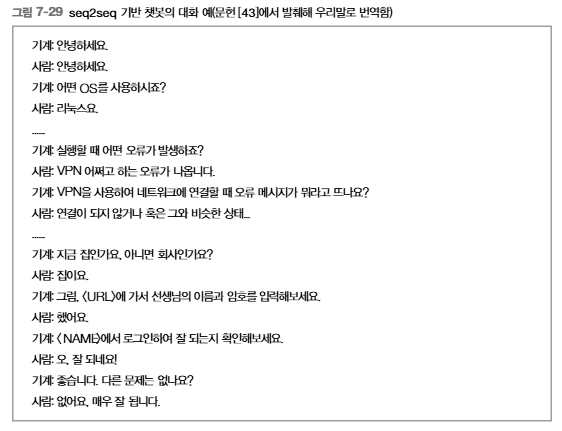   
- 그림의 대화를 보면, 기계(챗봇)는 훌륭하게 문제를 해결하고 있음
- VPN 연결이 되지 않는 사람을, 그 문제를 해결할 수 있는 URL 링크로 안내한 것
- 물론 이 챗봇은 IT 헬프데스크에 한정된 문제를 대상으로 하기 때문에 범용적으로 사용할 수는 없음
- 하지만 대화 기반으로 정답이나 힌트를 얻는 방식은 실용성이 높고 다양하게 응용하여 효과를 볼 수 있음

### 알고리즘 학습

이번 장에서 수행한 실험은 '덧셈'과 같은 간단한 문제였음   
그러나 원리적으로는 더 고차원적인 문제도 처리할 수 있음   
예컨대 파이썬 코드를 처리할 수도 있음   
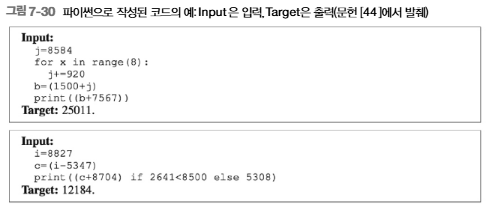   
- 소스 코드도 (자연어와 마찬가지로) 문자로 쓰여진 시계열 데이터
- 몇 줄에 걸친 코드라도 하나의 문장으로 처리할 수도 있음(줄바꿈은 개행 코드로 처리할 수 있음)
- 따라서 소스 코드를 그대로 seq2seq에 입력할 수 있고, 원하는 답과 대조하여 학습시킬 수 있는 것
- 그림에서 보듯, for 문이나 if 문이 포함된 문제는 일반적으로 잘 풀리지 않을 것
- 그러나 이런 문제라도 seq2seq의 틀에서 처리할 수 있음
- 그리고 seq2seq의 구조를 개선한다면 이런 문제도 결국 풀어낼 것으로 예상할 수 있음   

> 다음 장에서는 RNN을 확장한 NTM(Neural Turing Machine) 모델을 살펴봄   
> NTM 모델로는 컴퓨터(튜링 머신)가 메모리를 읽고 쓰는 순서를 학습하여 알고리즘을 재현할 예정   

### 이미지 캡셔닝

지금까지는 seq2seq가 텍스트를 다루는 예만을 보았음   
하지만 seq2seq는 텍스트 외에도, 이미지나 음성 등 다양한 데이터를 처리할 수 있음   
이번 절에서는 이미지를 문장으로 변환하는 **이미지 캡셔닝(Image Captioning)** 을 살펴봄   

이미지 캡셔닝은 '이미지'를 '문장'으로 변환함   
이 문제도 아래 그림과 같이 seq2seq의 틀에서 해결할 수 있음   
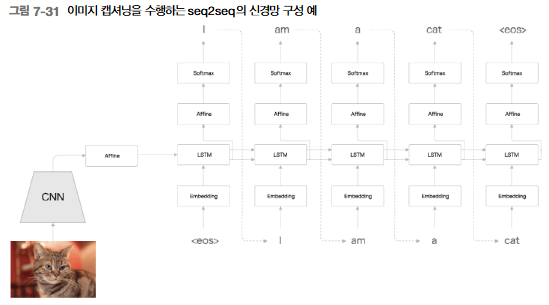   
- 그림은 이전에 본 친숙한 신경망 구성
- 지금까지와 다른 점은 Encoder가 LSTM에서 합성곱 신경망(Convolutional Neural Network)(CNN)으로 바뀐 것
- Decoder는 지금까지와 똑같은 신경망을 이용
- 겨우 이 정도의 변경(LSTM을 CNN으로 대체)만으로, seq2seq는 이미지도 처리할 수 있게 됨
- 그림의 CNN에 대해 조금 보충하면
    - 이 예에서는 이미지의 인코딩을 CNN이 수행함
    - 이때 CNN의 최종 출력은 특징 맵(feature map)
    - 특징 맵은 3차원(높이, 폭, 채널)이므로 이를 Decoder의 LSTM이 처리할 수 있도록 손질해야 함
    - 그래서 CNN의 특징 맵을 1차원으로 평탄화(flattening)한 후 완전연결인 Affine 계층에서 변환함
    - 그런 다음 변환된 데이터를 Decoder에 전달하면 지금까지와 같은 문장 생성을 수행할 수 있음   

> 그림의 CNN에는 VGG나 ResNet 등의 입증된 신경망을 사용하고, 가중치로는 다른 이미지 데이터셋(ImageNet 등)으로 학습을 끝낸 것을 이용함   
> 이렇게 하면 좋은 인코딩을 얻을 수 있고, 좋은 문장을 생성할 수 있음   

이제 seq2seq가 이미지 캡셔닝을 수행한 예를 몇 가지 살펴봄   
im2txt라는 텐서플로 코드로 생성된 예를 보면   
여기에 사용된 신경망은 아래 그림을 기초로 한 것이지만, 몇 가지 점을 개선했음   
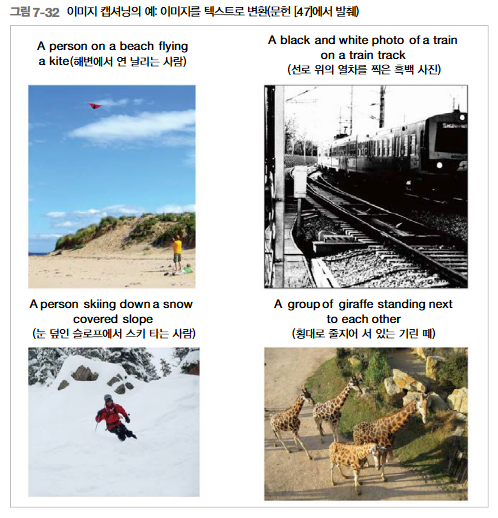   
- 그림을 보면 "A person on a beach flying a kite(해변에서 연 날리는 사람)"나 "A black and white photo of a train on a train track(선로 위의 열차를 찍은 흑백 사진)" 등 결과가 아주 훌륭함
- 이러한 결과로 이끈 비결은 이미지와 설명을 듬뿍 담은 학습 데이터(와 ImageNet 등의 대량의 이미지 데이터)에 있음
- 그리고 그 학습 데이터를 효율적으로 배울 수 있는 seq2seq가 존재하기에 이 그림과 같은 훌륭한 결과를 얻을 수 있는 것

## 정리

이번 장에서는 RNN을 이용한 문장 생성을 주제로 이야기를 진행했음   
6장에서 다룬 RNN을 사용한 언어 모델을 살짝 손질하여, 문장을 생성하는 기능을 추가했음   
이번 장의 후반부에서는 seq2seq에게 간단한 덧셈 문제를 학습시키는 데 성공했음   
seq2seq는 Encoder와 Decoder를 연결한 모델로, 결국 2개의 RNN을 조합한 단순한 구조   
하지만 그 단순함에도 불구하고 seq2seq는 매우 큰 가능성을 지니고 있어서 다양한 애플리케이션에 적용할 수 있음   

또한, 이번 장에서는 seq2seq를 개선하는 아이디어를 2개 소개하고(Reverse와 Peeky), 직접 구현해 평가하여 그 효과를 확인했음   
다음 장에서는 seq2seq를 한층 더 개선할 예정   
이때 등장하는 것이 바로 어텐션 - 딥러닝에서 가장 중요한 기법 중 하나   
다음 장에서는 어텐션 메커니즘을 설명하고 구현하여 한층 더 강력한 seq2seq를 구현할 것

### 이번 장에서 배운 내용

- RNN을 이용한 언어 모델은 새로운 문장을 생성할 수 있음
- 문장을 생성할 때는 하나의 단어(혹은 문자)를 주고 모델의 출력(확률분포)에서 샘플링하는 과정을 반복함
- RNN을 2개 조합함으로써 시계열 데이터를 다른 시계열 데이터로 변환할 수 있음
- seq2seq는 Encoder가 출발어 입력문을 인코딩하고, 인코딩된 정보를 Decoder가 받아 디코딩하여 도착어 출력문을 얻음
- 입력문을 반전시키는 기법(Reverse), 또는 인코딩된 정보를 Decoder의 여러 계층에 전달하는 기법(Peeky)은 seq2seq의 정확도 향상에 효과적
- 기계 번역, 챗봇, 이미지 캡셔닝 등 seq2seq는 다양한 애플리케이션에 이용할 수 있음